In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score

In [5]:
df = pd.read_csv('C:/Users/Pavel/Lessen_jypyter/csv/student.csv')

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'Id'}>],
       [<Axes: title={'center': 'Student_Age'}>,
        <Axes: title={'center': 'Weekly_Study_Hours'}>]], dtype=object)

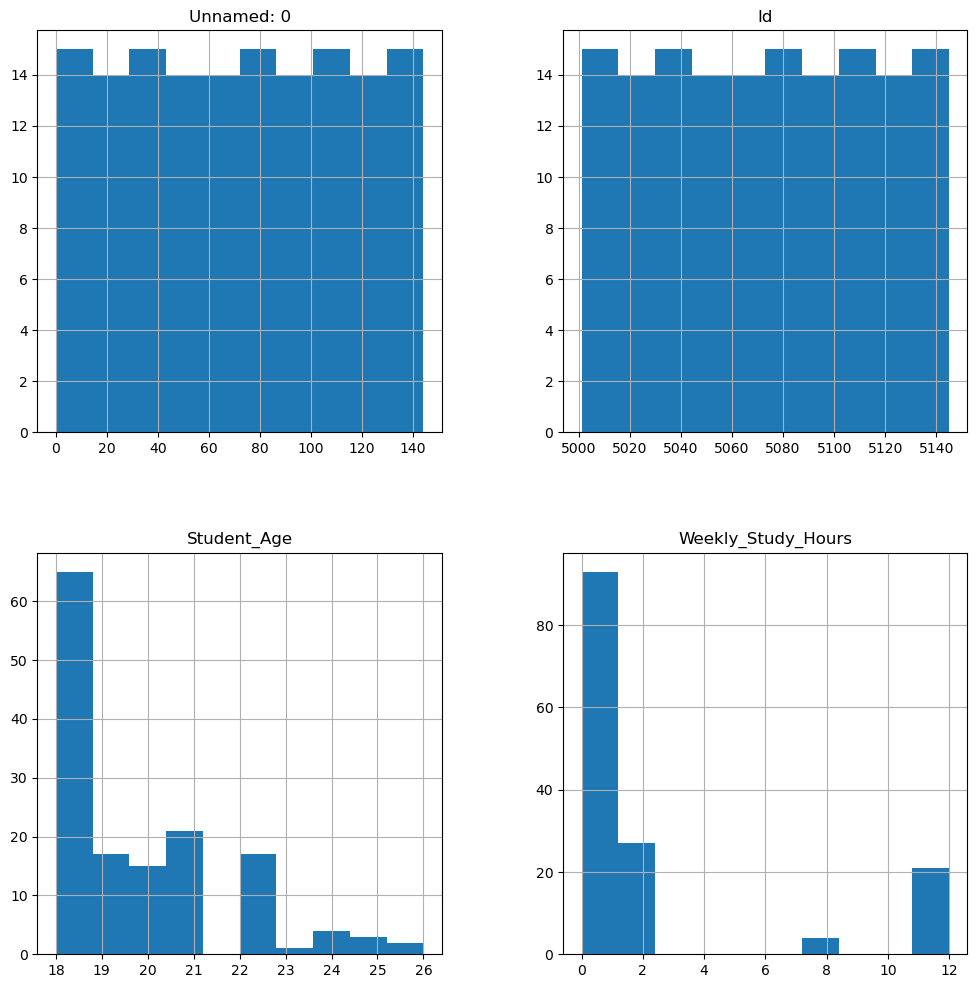

In [6]:
plt.rcParams['figure.figsize'] = [12, 12]
df.hist()

In [5]:
df.describe()

,Unnamed: 0,Id,Student_Age,Weekly_Study_Hours
count,145.000000,145.000000,145.000000,145.000000
mean,72.000000,5073.000000,19.682759,2.331034
std,42.001984,42.001984,1.992010,4.249273
min,0.000000,5001.000000,18.000000,0.000000
25%,36.000000,5037.000000,18.000000,0.000000
50%,72.000000,5073.000000,19.000000,0.000000
75%,108.000000,5109.000000,21.000000,2.000000
max,144.000000,5145.000000,26.000000,12.000000


In [6]:
df.head()

,Unnamed: 0,Id,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,0,5001,21,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,1,5002,20,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,2,5003,21,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,3,5004,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,4,5005,22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


In [4]:
df.dtypes

Unnamed: 0             int64
Id                     int64
Student_Age            int64
Sex                   object
High_School_Type      object
Scholarship           object
Additional_Work       object
Sports_activity       object
Transportation        object
Weekly_Study_Hours     int64
Attendance            object
Reading               object
Notes                 object
Listening_in_Class    object
Project_work          object
Grade                 object
dtype: object

In [5]:
print(df['High_School_Type'].unique())
print(df['Scholarship'].unique())
print(df['Additional_Work'].unique())
print(df['Sports_activity'].unique())
print(df['Transportation'].unique())
print(df['Attendance'].unique())
print(df['Reading'].unique())
print(df['Notes'].unique())
print(df['Listening_in_Class'].unique())
print(df['Project_work'].unique())
print(df['Grade'].unique())

['Other' 'State' 'Private']
['50%' '75%' '100%' '25%' nan]
['Yes' 'No']
['No' 'Yes']
['Private' 'Bus']
['Always' 'Never' 'Sometimes' '3']
['Yes' 'No']
['Yes' 'No' '6']
['No' 'Yes' '6']
['No' 'Yes']
['AA' 'BA' 'CC' 'Fail' 'BB' 'CB' 'DD' 'DC']


In [7]:
df = df.drop(columns=['Id'])

In [8]:
df['High_School_Type'] = df['High_School_Type'].map({'Other': 0, 'State': 1, 'Private': 2}).astype(float)
df['Scholarship'] = df['Scholarship'].map({'50%': 3,'75%': 2, '100%': 1, '25%': 0}).astype(float)
df['Additional_Work'] = df['Additional_Work'].map({'Yes': 1, 'No': 0}).astype(float)
df['Sports_activity'] = df['Sports_activity'].map({'Yes': 1, 'No': 0}).astype(float)
df['Transportation'] = df['Transportation'].map({'Private': 1, 'Bus': 0}).astype(float)
df['Attendance'] = df['Attendance'].map({'Always': 3,'Never': 2, 'Sometimes': 1, '3': 0}).astype(float)
df['Reading'] = df['Reading'].map({'Yes': 1, 'No': 0}).astype(float)
df['Notes'] = df['Notes'].map({'Yes': 2, 'No': 1, '6': 0}).astype(float)
df['Listening_in_Class'] = df['Listening_in_Class'].map({'Yes': 2, 'No': 1, '6': 0}).astype(float)
df['Project_work'] = df['Project_work'].map({'Yes': 1, 'No': 0}).astype(float)
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0}).astype(float)

In [6]:
df.head()

,Unnamed: 0,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,0,21,1.0,2.0,3.0,1.0,0.0,1.0,0,3.0,1.0,2.0,1.0,0.0,AA
1,1,20,1.0,2.0,3.0,1.0,0.0,1.0,0,3.0,1.0,1.0,2.0,1.0,AA
2,2,21,1.0,1.0,3.0,0.0,0.0,1.0,2,2.0,0.0,1.0,1.0,1.0,AA
3,3,18,0.0,0.0,3.0,1.0,0.0,0.0,2,3.0,0.0,2.0,1.0,0.0,AA
4,4,22,1.0,0.0,3.0,0.0,0.0,0.0,12,3.0,1.0,1.0,2.0,1.0,AA


In [7]:
df.isna().sum()

Unnamed: 0            0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64

In [9]:
df['Grade'] = df['Grade'].map({'AA': 7,
                                         'BA': 6,
                                         'BB': 5,
                                         'CB': 4,
                                         'CC': 3,
                                         'DC': 2,
                                         'DD': 1,
                                         'Fail': 0}).astype(int)

In [10]:
df.isna().sum()

Unnamed: 0            0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64

In [11]:
median_minpay = df['Scholarship'].median()
df['Scholarship'] = df['Scholarship'].fillna(median_minpay)

In [12]:
df.isna().sum()

Unnamed: 0            0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           0
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64

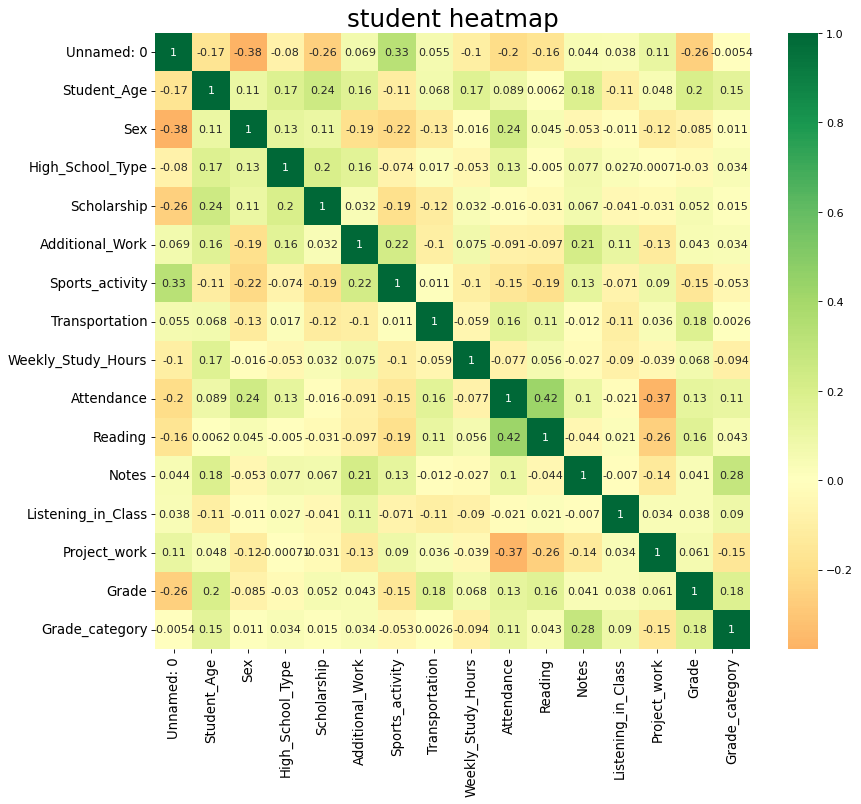

In [16]:
heatdf = df
plt.figure(figsize = (12,10), dpi = 80)
sns.heatmap(heatdf.corr(), xticklabels = heatdf.corr().columns, yticklabels = heatdf.corr().columns, cmap = 'RdYlGn', center = 0, annot = True)
plt.title('student heatmap', fontsize = 22)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()

In [17]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

df['Grade_category'] = pd.cut(df['Grade'], bins = [-1, 1, 3, 5, 7], labels = ['Неудовлетворительно', 'Удовлетворительно', 'Хорошист', 'Отличник'])
df['Grade_category'] = label_encoder.fit_transform(df['Grade_category'])

X = df.drop(['Grade', 'Grade_category'], axis = 1)
y = df['Grade_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
df.dtypes

Unnamed: 0              int64
Student_Age             int64
Sex                   float64
High_School_Type      float64
Scholarship           float64
Additional_Work       float64
Sports_activity       float64
Transportation        float64
Weekly_Study_Hours      int64
Attendance            float64
Reading               float64
Notes                 float64
Listening_in_Class    float64
Project_work          float64
Grade                   int64
Grade_category          int64
dtype: object

In [21]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

In [19]:
model = keras.Sequential([
    keras.Input(shape=(14,)),
    keras.layers.Dense(256, activation = 'relu'),
    keras.layers.Dense(128, activation = 'relu'),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(4)
])

model.compile(optimizer = 'adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True), metrics = ['accuracy'])

model.fit(X_train, y_train, epochs = 100, verbose = 0) 

from sklearn.metrics import f1_score, accuracy_score

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)
print('\nТестовая точность:', test_acc)
y_pred = model.predict(X_test).argmax(axis = 1)
print('F1-score:', f1_score(y_test, y_pred, average = 'macro'))
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy_score(y_test, y_pred))

1/1 - 0s - 248ms/step - accuracy: 0.4483 - loss: 1.6578

Тестовая точность: 0.4482758641242981
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
F1-score: 0.3038461538461539
Accuracy: 0.4482758620689655


In [22]:
from sklearn.linear_model import LogisticRegression 
constr = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr', solver='liblinear')
log_reg = OneVsRestClassifier(constr)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision_weighted:.4f}")
print(f"Recall:    {recall_weighted:.4f}")
print(f"F1-Score:  {f1_weighted:.4f}")

Accuracy:  0.5172
Precision: 0.4725
Recall:    0.5172
F1-Score:  0.4846


In [31]:
from sklearn.svm import SVC

svc_rbf = SVC(kernel = 'rbf', C = 1.0, random_state = 42, probability = True)
svc_rbf.fit(X_train_scaled, y_train)
y_pred_svc_rbf = svc_rbf.predict(X_test_scaled)
y_pred_proba_svc_rbf = svc_rbf.predict_proba(X_test_scaled)

accuracy_rbf = accuracy_score(y_test, y_pred_svc_rbf)
precision_rbf = precision_score(y_test, y_pred_svc_rbf, average = 'weighted', zero_division = 0)
recall_rbf = recall_score(y_test, y_pred_svc_rbf, average = 'weighted', zero_division = 0)
f1_rbf = f1_score(y_test, y_pred_svc_rbf, average = 'weighted', zero_division = 0)
print(f"Accuracy:  {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall:    {recall_rbf:.4f}")
print(f"F1-Score:  {f1_rbf:.4f}")

Accuracy:  0.4828
Precision: 0.4531
Recall:    0.4828
F1-Score:  0.3928


In [30]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors= 12)
knn.fit(X_train_scaled, y_train)
knn_predict = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, knn_predict)
precision_knn = precision_score(y_test, knn_predict, average = 'weighted', zero_division = 0)
recall_knn = recall_score(y_test, knn_predict, average = 'weighted', zero_division = 0)
f1_knn = f1_score(y_test, knn_predict, average = 'weighted', zero_division = 0)
print(f"Accuracy:  {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall:    {recall_rbf:.4f}")
print(f"F1-Score:  {f1_rbf:.4f}")

Accuracy:  0.4828
Precision: 0.4531
Recall:    0.4828
F1-Score:  0.3928


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, accuracy_score

In [32]:
tree = DecisionTreeClassifier( criterion='entropy', max_depth=5, min_samples_leaf=2,
                       min_samples_split=10, random_state=32
                            )
tree.fit(X_train_scaled, y_train)
tree_predict = tree.predict(X_test_scaled)
accuracy_tree = accuracy_score(y_test, tree_predict)
precision_tree = precision_score(y_test, tree_predict, average = 'weighted', zero_division = 0)
recall_tree = recall_score(y_test, tree_predict, average = 'weighted', zero_division = 0)
f1_tree = f1_score(y_test, tree_predict, average = 'weighted', zero_division = 0)
print(f"Accuracy:  {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall:    {recall_rbf:.4f}")
print(f"F1-Score:  {f1_rbf:.4f}")

Accuracy:  0.4828
Precision: 0.4531
Recall:    0.4828
F1-Score:  0.3928


In [34]:
random_forest = RandomForestClassifier(n_estimators=200,criterion='entropy', max_depth=5, min_samples_leaf=2,
                       min_samples_split=10, random_state=32)
random_forest.fit(X_train, y_train)
random_forest_predict = random_forest.predict(X_test_scaled)
accuracy_random_forest = accuracy_score(y_test, random_forest_predict)
precision_random_forest = precision_score(y_test, random_forest_predict, average = 'weighted', zero_division = 0)
recall_random_forest = recall_score(y_test, random_forest_predict, average = 'weighted', zero_division = 0)
f1_random_forest = f1_score(y_test, random_forest_predict, average = 'weighted', zero_division = 0)
print(f"Accuracy:  {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall:    {recall_rbf:.4f}")
print(f"F1-Score:  {f1_rbf:.4f}")

Accuracy:  0.4828
Precision: 0.4531
Recall:    0.4828
F1-Score:  0.3928


D:\Teachers\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [37]:
catboost = CatBoostClassifier(n_estimators=100,
                             learning_rate=0.1,
                             max_depth=6,
                             random_state=42,
                             verbose=False
                            )
catboost.fit(X_train_scaled, y_train)
catboost_predict = catboost.predict(X_test_scaled)
accuracy_catboost = accuracy_score(y_test, catboost_predict)
precision_catboost = precision_score(y_test, catboost_predict, average = 'weighted')
recall_catboost = recall_score(y_test, catboost_predict, average = 'weighted', zero_division = 0)
f1_catboost = f1_score(y_test, catboost_predict, average = 'weighted', zero_division = 0)
print(f"Accuracy:  {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall:    {recall_rbf:.4f}")
print(f"F1-Score:  {f1_rbf:.4f}")

Accuracy:  0.4828
Precision: 0.4531
Recall:    0.4828
F1-Score:  0.3928


In [79]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree_model = DecisionTreeClassifier(
    random_state=32,
    max_depth = 3, 
    min_samples_leaf = 20)
scoring = { 'Accuracy': 'accuracy_score', 'F1-Score': 'f1_score'}

# grid_search = GridSearchCV(
#     estimator=tree_model,
#     cv=5,
#     param_grid={'max_depth':[3], 'min_samples_leaf':[20]},
#     scoring = scoring,
#     refit='Accuracy',
#     n_jobs=-1
# )
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(estimator=tree_model, param_grid = param_grid, cv=5, scoring='accuracy', verbose=1)

grid_search.fit(X_train_scaled, y_train)
best_tree = grid_search.best_estimator_
grid_search_predict = grid_search.predict(X_test)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


D:\Aninst\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [77]:
print("Лучшее значение кросс-валидационной оценки:", grid_search.best_score_)

Лучшее значение кросс-валидационной оценки: 0.5518115942028985


In [76]:
grid_search.score

<bound method BaseSearchCV.score of GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=20,
                                              random_state=32),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=1)>